This Colab notebook is designed to evaluate Chirp's transcription performance relative to other models the team has previously analyzed.

**Note:** Rather than using [NeMo's](https://www.nvidia.com/en-us/ai-data-science/products/nemo/) implementation of WER, this Colab uses [JiWER](https://github.com/jitsi/jiwer) since it is lighterweight and usable in a vanilla Colab instance.

The Colab performs the following functions:

1.  **Defines helper functions** for advanced text normalization, specifically handling numbers and annotations for accurate WER calculation.
2.  **Merges transcription results from Chirp** (identified by a batch ID) with an existing ground truth benchmark manifest downloaded from GCS.
3.  **Generates and visualizes a WER leaderboard** comparing different ASR models (Chirp v3, Parakeet v2, Canary Flash) based on the merged data.
4.  **Exports the updated benchmark** (including Chirp's predictions) back to Google Cloud Storage. This output is formatting using the NeMo's manifest format.

Note: This Colab reads/writes content in the `wd-asr-chirp-evaluation` bucket in GCP.

In [74]:
# @title Install dependencies
!pip install -q jiwer num2words loguru

In [75]:
# @title Imports, constants, and auth
import json
import re
import os
import collections
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import jiwer
from num2words import num2words
from google.colab import auth
from google.cloud import storage
from loguru import logger
from typing import Any

GCP_PROJECT_ID = "automatic-hawk-481415-m9"
GCS_BUCKET = "wd-asr-chirp-evaluation"
GCS_OUTPUT_DIR = "transcripts"
GCS_MAP_DIR = "segmented_audio"
BATCH_MANIFEST_FILENAME = "batch_manifest.jsonl"
EXISTING_BENCHMARK_FILENAME = "playground_parakeet_and_canary_flash.json"
UPDATED_BENCHMARK_FILENAME = "playground_parakeet_and_canary_flash_and_chirp.jsonl"

# Authenticate to GCS
auth.authenticate_user()
!gcloud config set project {GCP_PROJECT_ID} --quiet

Updated property [core/project].


In [76]:
# @title Defining helper functions

class ExpandNumbersToWords(jiwer.AbstractTransform):
    def process_string(self, s: str) -> str:
        # Convert digits to words: "433" -> "four hundred and thirty-three"
        def replace_digits(match: re.Match) -> str:
            word_form = num2words(match.group(0))
            # Clean up the output so "thirty-three" matches "thirty three"
            return word_form.replace("-", " ").replace(",", "").replace(" and ", " ")

        return re.sub(r"\d+", replace_digits, s)

class RemoveAnnotations(jiwer.AbstractTransform):
    def process_string(self, s: str) -> str:
        # Surgically removes <anything> or [anything] even if touching punctuation
        s = re.sub(r"<[^>]+>", "", s)
        s = re.sub(r"\[[^\]]+\]", "", s)
        return s

class NormalizeDispatchQuirks(jiwer.AbstractTransform):
    def process_string(self, s: str) -> str:
        # Strip underscore placeholders (treat like <unknown>)
        s = re.sub(r"_+", "", s)

        # Strip fillers (uh, um, ah, er) so models aren't penalized for readability
        s = re.sub(r"\b(uh|um|ah|er)\b", "", s, flags=re.IGNORECASE)

        # Turn hyphens into spaces (e.g., "14A-alpha" -> "14A alpha")
        # Prevents words from getting glued together when punctuation is removed
        s = s.replace("-", " ")

        return s

def load_manifest(path: str) -> list[dict[str, Any]]:
    """Helper to load manifest. Cleans up formatting issues and stray linefeeds."""
    data = []
    if not os.path.exists(path):
        logger.error(f"Manifest path not found: {path}")
        return []

    with open(path, "r", encoding="utf-8") as f:
        content = f.read().strip()

    # Handle JSON array format
    if content.startswith("["):
        try:
            data = json.loads(content)
        except json.JSONDecodeError as e:
            logger.error(f"Failed to parse JSON array: {e}")
            return []
    else:
        # Safely split JSONL even if there are literal newlines inside the strings
        raw_objects = re.split(r"}\s*\n\s*{", content)
        for i, obj_str in enumerate(raw_objects):
            # Re-add braces stripped by the regex split
            if not obj_str.startswith("{"): obj_str = "{" + obj_str
            if not obj_str.endswith("}"): obj_str = obj_str + "}"
            try:
                data.append(json.loads(obj_str))
            except json.JSONDecodeError:
                logger.warning(f"Skipping malformed JSON object at index {i}")

    # Sanitize text fields to remove escaped linefeeds
    for row in data:
        if "text" in row and row["text"]:
            row["text"] = row["text"].replace("\n", " ").replace("\r", " ")
        for key in row.keys():
            if key.startswith("pred_text_") and isinstance(row[key], str):
                row[key] = row[key].replace("\n", " ").replace("\r", " ")

    return data

def generate_leaderboard(manifest_path: str) -> pd.DataFrame:
    manifest_data = load_manifest(manifest_path)
    refs = [d["text"] for d in manifest_data]
    chirp_hyps = [d["pred_text_chirp_v3"] for d in manifest_data]
    parakeet_hyps = [d["pred_text_parakeet-tdt-06b-v2"] for d in manifest_data]
    canary_hyps = [d["pred_text_canary-1b-flash"] for d in manifest_data]

    radio_pipeline = jiwer.Compose([
        ExpandNumbersToWords(),
        RemoveAnnotations(),
        NormalizeDispatchQuirks(),
        jiwer.SubstituteRegexes({r"[\n\r\t]+": " "}),
        jiwer.ToLowerCase(),
        jiwer.ExpandCommonEnglishContractions(),
        jiwer.RemovePunctuation(),
        jiwer.RemoveWhiteSpace(replace_by_space=True),
        jiwer.RemoveMultipleSpaces(),
        jiwer.Strip(),
        jiwer.ReduceToListOfListOfWords()
    ])

    results = {
        "Chirp v3": jiwer.wer(refs, chirp_hyps, radio_pipeline, radio_pipeline) * 100,
        "Parakeet v2": jiwer.wer(refs, parakeet_hyps, radio_pipeline, radio_pipeline) * 100,
        "Canary Flash": jiwer.wer(refs, canary_hyps, radio_pipeline, radio_pipeline) * 100
    }

    df = pd.DataFrame(list(results.items()), columns=["Model", "WER (%)"]).sort_values("WER (%)")
    logger.info("\nUpdated Benchmark Results\n")

    plt.figure(figsize=(10, 6))
    sns.barplot(x="Model", y="WER (%)", hue="Model", data=df, palette="viridis", legend=False)
    for index, value in enumerate(df["WER (%)"]):
        plt.text(index, value + 0.5, f"{value:.2f}%", ha="center", fontweight="bold")
    plt.title("Word Error Rate (WER) by Model", fontsize=14)
    plt.show()

    return df

def merge_gcs_results_to_manifest(
    baseline_data: list[dict[str, Any]],
    batch_manifest_data: list[dict[str, Any]],
    gcs_bucket_name: str,
    output_file: str
) -> list[dict[str, Any]]:
    client = storage.Client(project=GCP_PROJECT_ID)
    bucket = client.bucket(gcs_bucket_name)

    logger.info(f"Fetching Chirp transcripts from gs://{gcs_bucket_name}/{GCS_OUTPUT_DIR}/...")
    transcript_blobs = list(bucket.list_blobs(prefix=f"{GCS_OUTPUT_DIR}/"))

    # 1. Fetch transcript blobs and extract the full predicted text
    chirp_predictions = {}
    for blob in transcript_blobs:
        if not blob.name.endswith(".json"): continue

        # Extract example_id and seg_id from the filename
        match = re.search(r"([^/]+)__seg(\d{3})", os.path.basename(blob.name))
        if not match: continue

        raw_id = match.group(1)
        example_id = raw_id[12:] if raw_id.startswith("transcripts_") else raw_id
        seg_key = match.group(2)

        # Read the JSON and extract the top alternative
        data = json.loads(blob.download_as_text())
        transcript_parts = []
        for res in data.get("results", []):
            alts = res.get("alternatives", [])
            if alts:
                top_alt = alts[0]
                if "transcript" in top_alt:
                    transcript_parts.append(top_alt["transcript"])

        chirp_predictions[(example_id, seg_key)] = " ".join(transcript_parts).strip()

    # 2. Map batch manifest: (example_id, seg_id) -> offset
    offset_to_seg = collections.defaultdict(dict)
    for entry in batch_manifest_data:
        e_id = entry.get("example_id", "")
        s_id = entry.get("segment_id", "")
        offset = float(entry.get("offset", 0.0))
        offset_to_seg[e_id][s_id] = offset

    # 3. Match the Playground Baseline to the Chirp Predictions
    merged_records = []
    unmatched_count = 0

    for b_info in baseline_data:
        example_id = os.path.splitext(os.path.basename(b_info["audio_filepath"]))[0]
        b_offset = float(b_info.get("offset", 0.0))

        # Find matching seg_id by checking offsets
        matched_seg_id = None
        if example_id in offset_to_seg:
            for s_id, m_offset in offset_to_seg[example_id].items():
                # Relaxed tolerance to 0.25s
                if abs(b_offset - m_offset) < 0.25:
                    matched_seg_id = s_id
                    break

        # Grab the predicted text if we found a match
        chirp_text = ""
        if matched_seg_id and (example_id, matched_seg_id) in chirp_predictions:
            chirp_text = chirp_predictions[(example_id, matched_seg_id)]
        else:
            unmatched_count += 1
            logger.warning(f"Missed Match: No Chirp transcript found for {example_id} at offset {b_offset}")

        # Rebuild the payload
        record = {
            "audio_filepath": b_info["audio_filepath"],
            "text": b_info.get("text", ""),
            "pred_text_chirp_v3": chirp_text,
            "pred_text_parakeet-tdt-06b-v2": b_info.get("pred_text_parakeet-tdt-06b-v2", ""),
            "pred_text_canary-1b-flash": b_info.get("pred_text_canary-1b-flash", ""),
            "duration": b_info.get("duration", 0.0),
            "offset": b_offset,
            "lang": b_info.get("lang", "en")
        }
        merged_records.append(record)

    # Throw a loud error if records are silently failing
    if unmatched_count > 0:
        logger.error(f"WARNING: {unmatched_count} benchmark rows failed to map to a Chirp prediction!")

    with open(output_file, "w", encoding="utf-8") as f_out:
        for rec in merged_records:
            f_out.write(json.dumps(rec) + "\n")

    logger.info(f"Successfully wrote {len(merged_records)} merged records to {output_file}")
    return merged_records

def run_evaluation_pipeline() -> pd.DataFrame:
    # Load the ground truth benchmark (Parakeet/Canary baseline)
    baseline_data = load_manifest(EXISTING_BENCHMARK_FILENAME)

    # Download and load the batch manifest from Notebook 1 to map the offsets
    if not os.path.exists(BATCH_MANIFEST_FILENAME):
        gcs_path = f"{GCS_MAP_DIR}/{BATCH_MANIFEST_FILENAME}"
        storage.Client(project=GCP_PROJECT_ID).bucket(GCS_BUCKET).blob(gcs_path).download_to_filename(BATCH_MANIFEST_FILENAME)

    batch_manifest_data = load_manifest(BATCH_MANIFEST_FILENAME)
    # Merge Chirp's predictions into the baseline and generate the leaderboard
    merge_gcs_results_to_manifest(baseline_data, batch_manifest_data, GCS_BUCKET, UPDATED_BENCHMARK_FILENAME)
    return generate_leaderboard(UPDATED_BENCHMARK_FILENAME)

def export_master_playground() -> None:
    # Upload the final manifest to GCS
    storage.Client(project=GCP_PROJECT_ID).bucket(GCS_BUCKET).blob(UPDATED_BENCHMARK_FILENAME).upload_from_filename(UPDATED_BENCHMARK_FILENAME)

2026-03-05 21:09:31.532 | INFO     | __main__:merge_gcs_results_to_manifest:121 - Fetching Chirp transcripts from gs://wd-asr-chirp-evaluation/transcripts/...
2026-03-05 21:09:34.005 | INFO     | __main__:merge_gcs_results_to_manifest:203 - Successfully wrote 35 merged records to playground_parakeet_and_canary_flash_and_chirp.jsonl
2026-03-05 21:09:34.544 | INFO     | __main__:generate_leaderboard:101 - 
Updated Benchmark Results



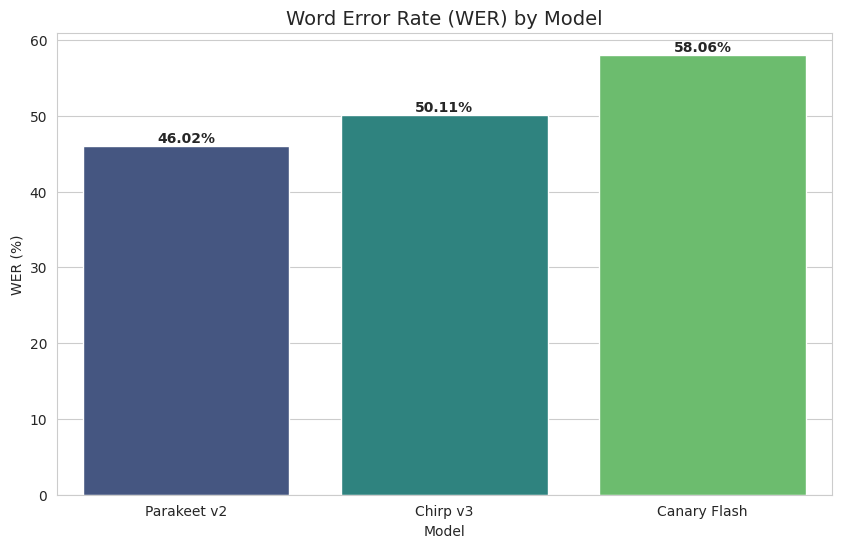

,Model,WER (%)
1,Parakeet v2,46.021505
0,Chirp v3,50.107527
2,Canary Flash,58.064516


In [77]:
# @title Compare Chirp performance and output the updated playground manifest
df_leaderboard = run_evaluation_pipeline()

export_master_playground()

df_leaderboard